✅ Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.74      0.53      0.61        59
           1       0.82      0.92      0.87       141

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



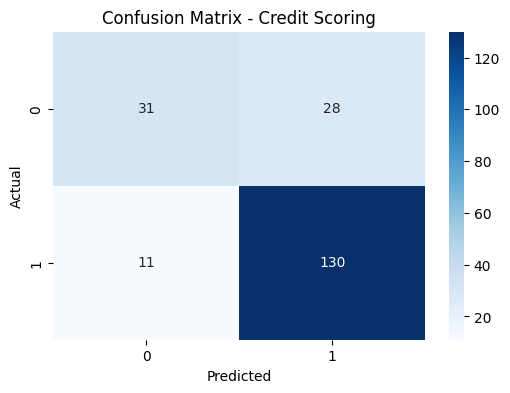

In [ ]:
# Complete Credit Scoring Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset load
cols = ['Status','Duration','CreditHistory','Purpose','CreditAmount',
        'Savings','Employment','InstallmentRate','PersonalStatus',
        'Debtors','ResidenceDuration','Property','Age','OtherInstallments',
        'Housing','ExistingCredits','Job','Dependents','Phone','ForeignWorker','Risk']

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data',
                 sep=' ', header=None, names=cols)

df['Risk'] = df['Risk'].map({1:'good', 2:'bad'})

# Encoding
le = LabelEncoder()
df_model = df.copy()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Train/Test
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Credit Scoring')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()